[Home](../../README.md)

### Model Evaluation

This is a demonstration of evaluating a model.

#### Step 1

Load the required dependencies.


In [7]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("../../style_Matplotlib_charts.mplstyle")
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import pickle

####  Step 2

Load the model for testing

In [8]:
filename = 'my_saved_model_v1.sav'
model_A = pickle.load(open(filename, 'rb'))


(Optional) Load a second model if you want to do comparative testing

In [9]:
filename = 'my_saved_model_v2.sav'
model_B = pickle.load(open(filename, 'rb'))

####  Step 3
Open and parse the test data CSV file and store the data as variable array data objects.

In [10]:
x_col = 'GoldXpAdvantage'
testing_data = pd.read_csv('2.4.1.testing_data.csv')
x_test = np.array(testing_data[x_col]).reshape(-1,1)
y_test = np.array(testing_data['blueWin'])

#### Step 5

Plot the test data features, targets and linear regression model to visually evaluate the model.

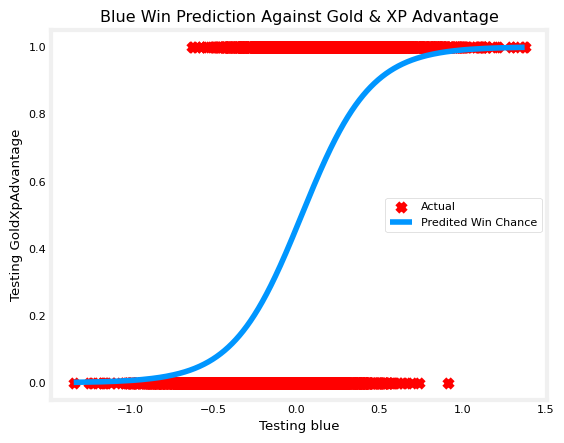

In [ ]:
y_pred = model_A.predict(x_test)
plt.scatter(x_test, y_test, marker='x', c='r', label='Actual')
# this plots the sigmoid curve of the predicted probabilities for blue winning against the gold and xp advantage
plt.plot(
    sorted(x_test.flatten()),
    [model_A.predict_proba([[v]])[0][1] for v in sorted(x_test.flatten())],
    label='Predited Win Chance'
)
plt.title("Blue Win Prediction Against Gold & XP Advantage")
plt.ylabel(f'Testing {x_col}')
plt.xlabel(f'Testing blue')
plt.legend()
plt.show()

*With added decision boundary and 50% winrate Threshold visualised*

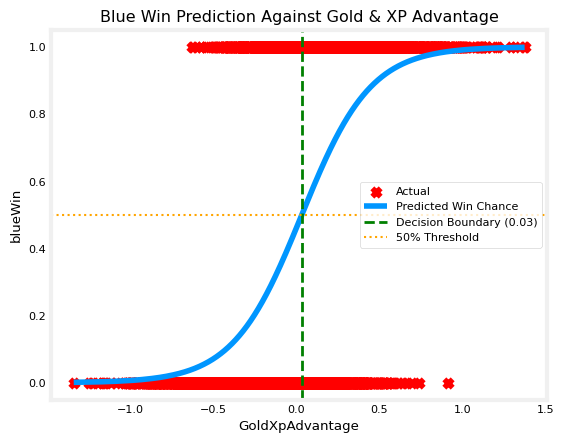

In [12]:
y_pred = model_A.predict(x_test)

# Find decision boundary where probability = 0.5
boundary = -model_A.intercept_[0] / model_A.coef_[0][0]

plt.scatter(x_test, y_test, marker="x", c="r", label="Actual")
plt.plot(
    sorted(x_test.flatten()),
    [model_A.predict_proba([[v]])[0][1] for v in sorted(x_test.flatten())],
    label="Predicted Win Chance",
)
# Decision boundary vertical line
plt.axvline(
    x=boundary,
    c="g",
    linestyle="--",
    linewidth=2,
    label=f"Decision Boundary ({boundary:.2f})",
)
# Horizontal 0.5 probability line
plt.axhline(y=0.5, c="orange", linestyle=":", linewidth=1.5, label="50% Threshold")
plt.title("Blue Win Prediction Against Gold & XP Advantage")
plt.ylabel("blueWin")
plt.xlabel(x_col)
plt.legend()
plt.show()

#### Step 6

Use the 'score' method of the `LogisticRegression` class to return a score based evaluation of the models accuracy or performance.

- Precision: For every predicted 'Win' how many were correct? | High precision = few false postives
- Recall: For every actual 'Win' how many were caught | High recall = few false negatives
- F1-Score: The balance between precision and recall
- Support: How many actual samples were used
- Accuracy: Shows how many predicitons were correct
- Macro average: every class treated as the same
- Weighted average: more weight to larger classes

In [ ]:
y_pred = model_A.predict(x_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
# Reports the precision, recall, f1-score and support for each class, overall accuracy, macro average, and weighted average
print(classification_report(y_test, y_pred, target_names=["Red Win", "Blue Win"]))

Accuracy Score: 0.7494

Classification Report:
              precision    recall  f1-score   support

     Red Win       0.75      0.76      0.75      3055
    Blue Win       0.75      0.74      0.74      2954

    accuracy                           0.75      6009
   macro avg       0.75      0.75      0.75      6009
weighted avg       0.75      0.75      0.75      6009



#### Confusion Matrix
A confusion matrix is a table used to evaluate classification models by comparing predicted classes against actual values. It shows: True Positives, True Negatives, False Positives, False Negatives, which reveals where the model is getting confused

*Top-Left: True postive | Top-Right: False Negative | Bottom-Left: False Positive | Bottom-Right: True Negative*

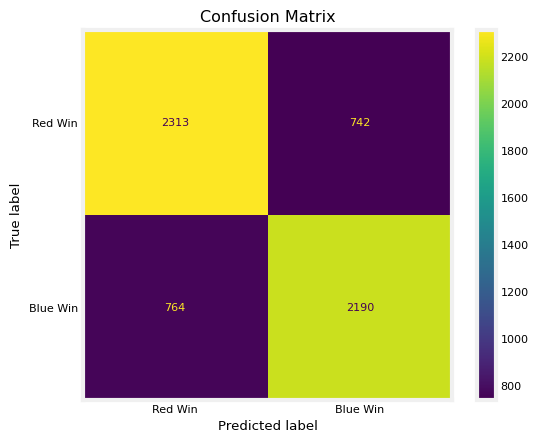

In [14]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Red Win", "Blue Win"]
)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

#### Step 7

Manually calculate and evaluate the 'loss' and 'cost' of the model using the test data.

In [15]:
# Calculate predicited probabilites for blue winning
y_pred_prob = model_A.predict_proba(x_test)[:, 1]

# Creates a table comparing actual values to predicted values, predicted probabilities, correctness, and loss
table = pd.DataFrame(
    {
        x_col: x_test.flatten(),
        "Actual": y_test,
        "Predicted": y_pred,
        "Predicted Probability": y_pred_prob.round(4),
        "Correct": y_pred == y_test,
        "Loss": abs(y_pred - y_test) ** 2,
    }
)

# Calculate the cost or average loss of the model
cost = 1 / (2 * len(table)) * table["Loss"].sum()
print(f"The cost or average loss of this model is {cost:.4f}")
print(f"Overall Accuracy: {(table['Correct'].sum() / len(table)):.4f}")
print(table)

The cost or average loss of this model is 0.1253
Overall Accuracy: 0.7494
      GoldXpAdvantage  Actual  Predicted  Predicted Probability  Correct  Loss
0             -0.1877       0          0                 0.2551     True     0
1              0.1754       0          1                 0.6636    False     1
2             -0.1345       0          0                 0.3068     True     0
3              0.1311       1          1                 0.6143     True     0
4              0.2707       1          1                 0.7574     True     0
...               ...     ...        ...                    ...      ...   ...
6004          -0.0075       1          0                 0.4495    False     1
6005          -0.6952       0          0                 0.0288     True     0
6006          -0.4156       0          0                 0.1024     True     0
6007          -0.0761       0          0                 0.3697     True     0
6008           0.3358       1          1                 

You may want to do some manual predictions to understand your model.

In [16]:
print(model_A.predict([[-.5]]))
print(model_A.predict([[1]]))

[0]
[1]


#### Step 8

Evaluate the X axis intercept and gradient or coefficient of your model by using the getter methods to return the intercept and coefficient from my_model() object.

In [17]:
print(f'X Axis intercept: {model_A.intercept_}')
print(f'Coefficient: {model_A.coef_}')

X Axis intercept: [-0.16664159]
Coefficient: [[4.82214961]]


#### Step 9. Multiple Variable Logistic Regression

You should be able to understand the code snippets with less guidelines.

In [18]:
filename = 'my_saved_model_v2.sav'
model_C = pickle.load(open(filename, 'rb'))

In [19]:
mx_col = ["KillDiff", "TowerDiff", "CsDiff"]
testing_data = pd.read_csv("2.4.1.testing_data.csv")
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data["blueWin"])

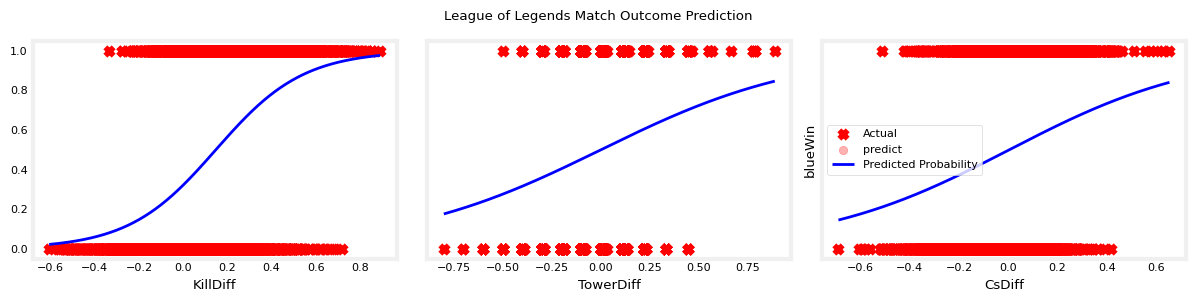

In [20]:
my_pred = model_C.predict(mx_test)

# plot predictions vs Actual    
fig,ax=plt.subplots(1,len(mx_col),figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(mx_test[:,i],my_test, label = 'Actual', marker='x', c='r')
    ax[i].scatter(mx_test[:,i],my_pred,color="r", label = 'predict', alpha=.3)

    x_range = np.linspace(mx_test[:,i].min(), mx_test[:,i].max(), 300)
    x_mean = np.mean(mx_test, axis=0)
    x_input = np.tile(x_mean, (300, 1))
    x_input[:, i] = x_range
    y_pred_sigmoid = model_C.predict_proba(x_input)[:, 1]

    ax[i].plot(x_range, y_pred_sigmoid, color='blue', linewidth=2, label='Predicted Probability')
    ax[i].set_xlabel(mx_col[i])

ax[i].set_ylabel("blueWin")
ax[i].legend()
fig.suptitle("League of Legends Match Outcome Prediction")
plt.tight_layout()
plt.show()

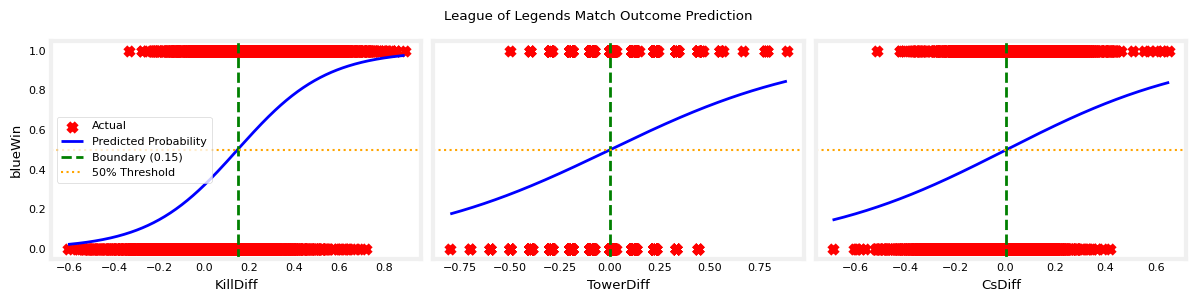

In [21]:
my_pred = model_C.predict(mx_test)

fig, ax = plt.subplots(1, len(mx_col), figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(mx_test[:, i], my_test, marker="x", c="r", label="Actual")

    # Sigmoid curve for this feature, others held at mean
    x_range = np.linspace(mx_test[:, i].min(), mx_test[:, i].max(), 300)
    x_mean = np.mean(mx_test, axis=0)
    x_input = np.tile(x_mean, (300, 1))
    x_input[:, i] = x_range
    sigmoid_probs = model_C.predict_proba(x_input)[:, 1]

    ax[i].plot(
        x_range, sigmoid_probs, color="blue", linewidth=2, label="Predicted Probability"
    )

    # Decision boundary where probability = 0.5
    boundary_idx = np.argmin(np.abs(sigmoid_probs - 0.5))
    boundary = x_range[boundary_idx]
    ax[i].axvline(
        x=boundary,
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"Boundary ({boundary:.2f})",
    )
    ax[i].axhline(
        y=0.5, color="orange", linestyle=":", linewidth=1.5, label="50% Threshold"
    )

    ax[i].set_xlabel(mx_col[i])

ax[0].set_ylabel("blueWin")
ax[0].legend()
fig.suptitle("League of Legends Match Outcome Prediction")
plt.tight_layout()
plt.show()

In [22]:
test_score = model_C.score(mx_test, my_test)
print(f'Training data score: {test_score}')

Training data score: 0.7427192544516559


In [23]:
print(model_C.predict([[0.1,0.1,0.1]]))
print(model_C.predict([[1,0.5,1]]))

[1]
[1]


In [24]:
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data['blueWin'] = my_test
data['Predicted result'] = model_C.predict(mx_test)
data['Loss'] = abs(model_C.predict(mx_test).round(2) - my_test)**2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()
print(f"The cost or average loss of this model is {cost}")

print(table)

The cost or average loss of this model is 0.1286403727741721
      KillDiff  TowerDiff  CsDiff  blueWin  Predicted result  Loss
0      -0.0322     0.0000 -0.0844        0                 0     0
1       0.1299     0.1111  0.0205        0                 1     1
2       0.0333     0.0111  0.0268        0                 0     0
3       0.0530     0.1111  0.0247        1                 0     1
4       0.2069     0.0000 -0.0555        1                 1     0
...        ...        ...     ...      ...               ...   ...
6004    0.2225    -0.1000 -0.0681        1                 1     0
6005   -0.3877    -0.1889 -0.4661        0                 0     0
6006   -0.1746    -0.2000 -0.3255        0                 0     0
6007    0.0301     0.0000 -0.0869        0                 0     0
6008    0.0489     0.1111  0.0944        1                 1     0

[6009 rows x 6 columns]


In [25]:
print(f'X Axis intercept: {model_C.intercept_}')
print(f'Coefficient: {model_C.coef_}')

X Axis intercept: [-0.66220309]
Coefficient: [[5.05036766 1.92959132 2.55948308]]


#### Step 11

When your model is ready for operations, move it to the [3.Operations\3.1.Deploy_Model](\3.Operations\3.1.Deploy_Model) folder.